In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

import sys
sys.path.append("../examples/WLS/")
sys.path.append("../src/")

plt.style.use("seaborn-v0_8-whitegrid")


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib import rcParams

import matplotlib as mpl

# Use the same discrete 5-level colormap from multifidelity plot
n_levels = 5  # same as before
cmap = plt.cm.plasma
color_values = np.linspace(0.75, 0.0, n_levels)  # same range
print(color_values)
color_values = color_values  # ensure LF→HF matches previous ordering

# Neutral gray for Xi
gray_color = "#A9A9A9"
gray_color = "#B0B0B0"  # coefficient matrix Xi remains neutral gray

colors = [cmap(c) for c in color_values[-1:-6:-1]]  # list of RGBA colors
colors = [gray_color for c in color_values[-1:-6:-1]]  # list of RGBA colors

# Fonts (LaTeX-like)
rcParams["font.family"] = "STIXGeneral"
rcParams["mathtext.fontset"] = "stix"


def draw_bracket(ax, x0, y0, width, height, side="left", lw=2.5, color="black"):
    """Draws square-style brackets."""
    if side == "left":
        xs = [x0 + width, x0, x0, x0 + width]
    else:
        xs = [x0, x0 + width, x0 + width, x0]
    ys = [y0 + height, y0 + height, y0, y0]
    for i in range(3):
        ax.add_line(Line2D([xs[i], xs[i + 1]], [ys[i], ys[i + 1]], lw=lw, color=color))

def fill_rows(ax, x_list, y0, h, w, n_rows, row_mask=None, ordered_colors=None):
    """Fill rectangular rows with contiguous colors."""
    ys = np.linspace(y0, y0 + h, n_rows + 1)

    if ordered_colors is None:
        ordered_colors = ["#cccccc"]

    # Split rows into contiguous thirds
    n_per_color = max(1, n_rows // len(ordered_colors))
    row_colors = []
    for c in ordered_colors:
        row_colors.extend([c] * n_per_color)
    # Fill any rounding mismatch
    while len(row_colors) < n_rows:
        row_colors.append(ordered_colors[-1])

    for i in range(n_rows):
        if (row_mask is None) or row_mask[i]:
            c = row_colors[i]
            for x in x_list:
                ax.add_patch(
                    Rectangle(
                        (x, ys[i]),
                        w,
                        ys[i + 1] - ys[i],
                        facecolor=c,
                        edgecolor="white",
                        linewidth=0.3,
                    )
                )
def draw_variant(filename="out.svg", n_rows=30, row_mask=None):
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.set_xlim(0, 170)
    ax.set_ylim(0, 100)
    ax.axis("off")

    base_y, h, w, gap = 20, 70, 3.0, 2.0

    # ----- Left block: U_t -----
    Lx = 10
    L_cols = [Lx + i * (w + gap) for i in range(3)]
    fill_rows(ax, L_cols, base_y, h, w, n_rows,
              row_mask=row_mask,
              ordered_colors=colors)
    draw_bracket(ax, Lx - 4, base_y, 2.5, h, side="left")
    draw_bracket(ax, Lx + 2.7 * (w + gap), base_y, 2.5, h, side="right")

        # ----- Middle block: Θ(U) -----
    Mx = Lx + 3 * (w + gap) + 14   # was 20 → now tighter
    middle_gap = gap * 0.65        # reduce spacing only in Θ block

    M_cols_left = [Mx + i * (w + middle_gap) for i in range(4)]
    dots_x = Mx + 4 * (w + middle_gap) + 6   # was 10 → reduced
    zx = dots_x + 12                          # was 18 → reduced
    fill_rows(ax, M_cols_left, base_y, h, w, n_rows,
              row_mask=row_mask,
              ordered_colors=colors)
    fill_rows(ax, [zx], base_y, h, w, n_rows,
              row_mask=row_mask,
              ordered_colors=colors)
    draw_bracket(ax, Mx - 4, base_y, 2.5, h, side="left")
    draw_bracket(ax, zx + w + 2, base_y, 2.5, h, side="right")

    # ----- Right block: Xi (always full, no subsampling) -----
    Rx = zx + w + 12
    R_base_y = base_y + 10
    R_h = h - 10
    R_cols = [Rx + i * (w + gap) for i in range(3)]
    fill_rows(ax, R_cols, R_base_y, R_h, w, n_rows,
              row_mask=np.ones(n_rows, dtype=bool),   # <-- no subsampling
              ordered_colors=[gray_color])
    draw_bracket(ax, Rx - 5, R_base_y, 2.5, R_h, side="left")
    draw_bracket(ax, Rx + 2.5 * (w + gap) + 2, R_base_y, 2.5, R_h, side="right")

    plt.savefig(filename, format="png", bbox_inches="tight", transparent=True)
    plt.close()

# ---------------- Generate 4 images ----------------
n_rows = 30
keep_fraction = 0.6

# Full version
draw_variant(filename="sindy_full.png", n_rows=n_rows, row_mask=None)

# Three ensemble subsamples
for k in range(1, 4):
    rng = np.random.default_rng(seed=k)
    row_mask = rng.random(n_rows) < keep_fraction
    draw_variant(filename=f"sindy_ensemble_{k}.png", n_rows=n_rows, row_mask=row_mask)


[0.75   0.5625 0.375  0.1875 0.    ]


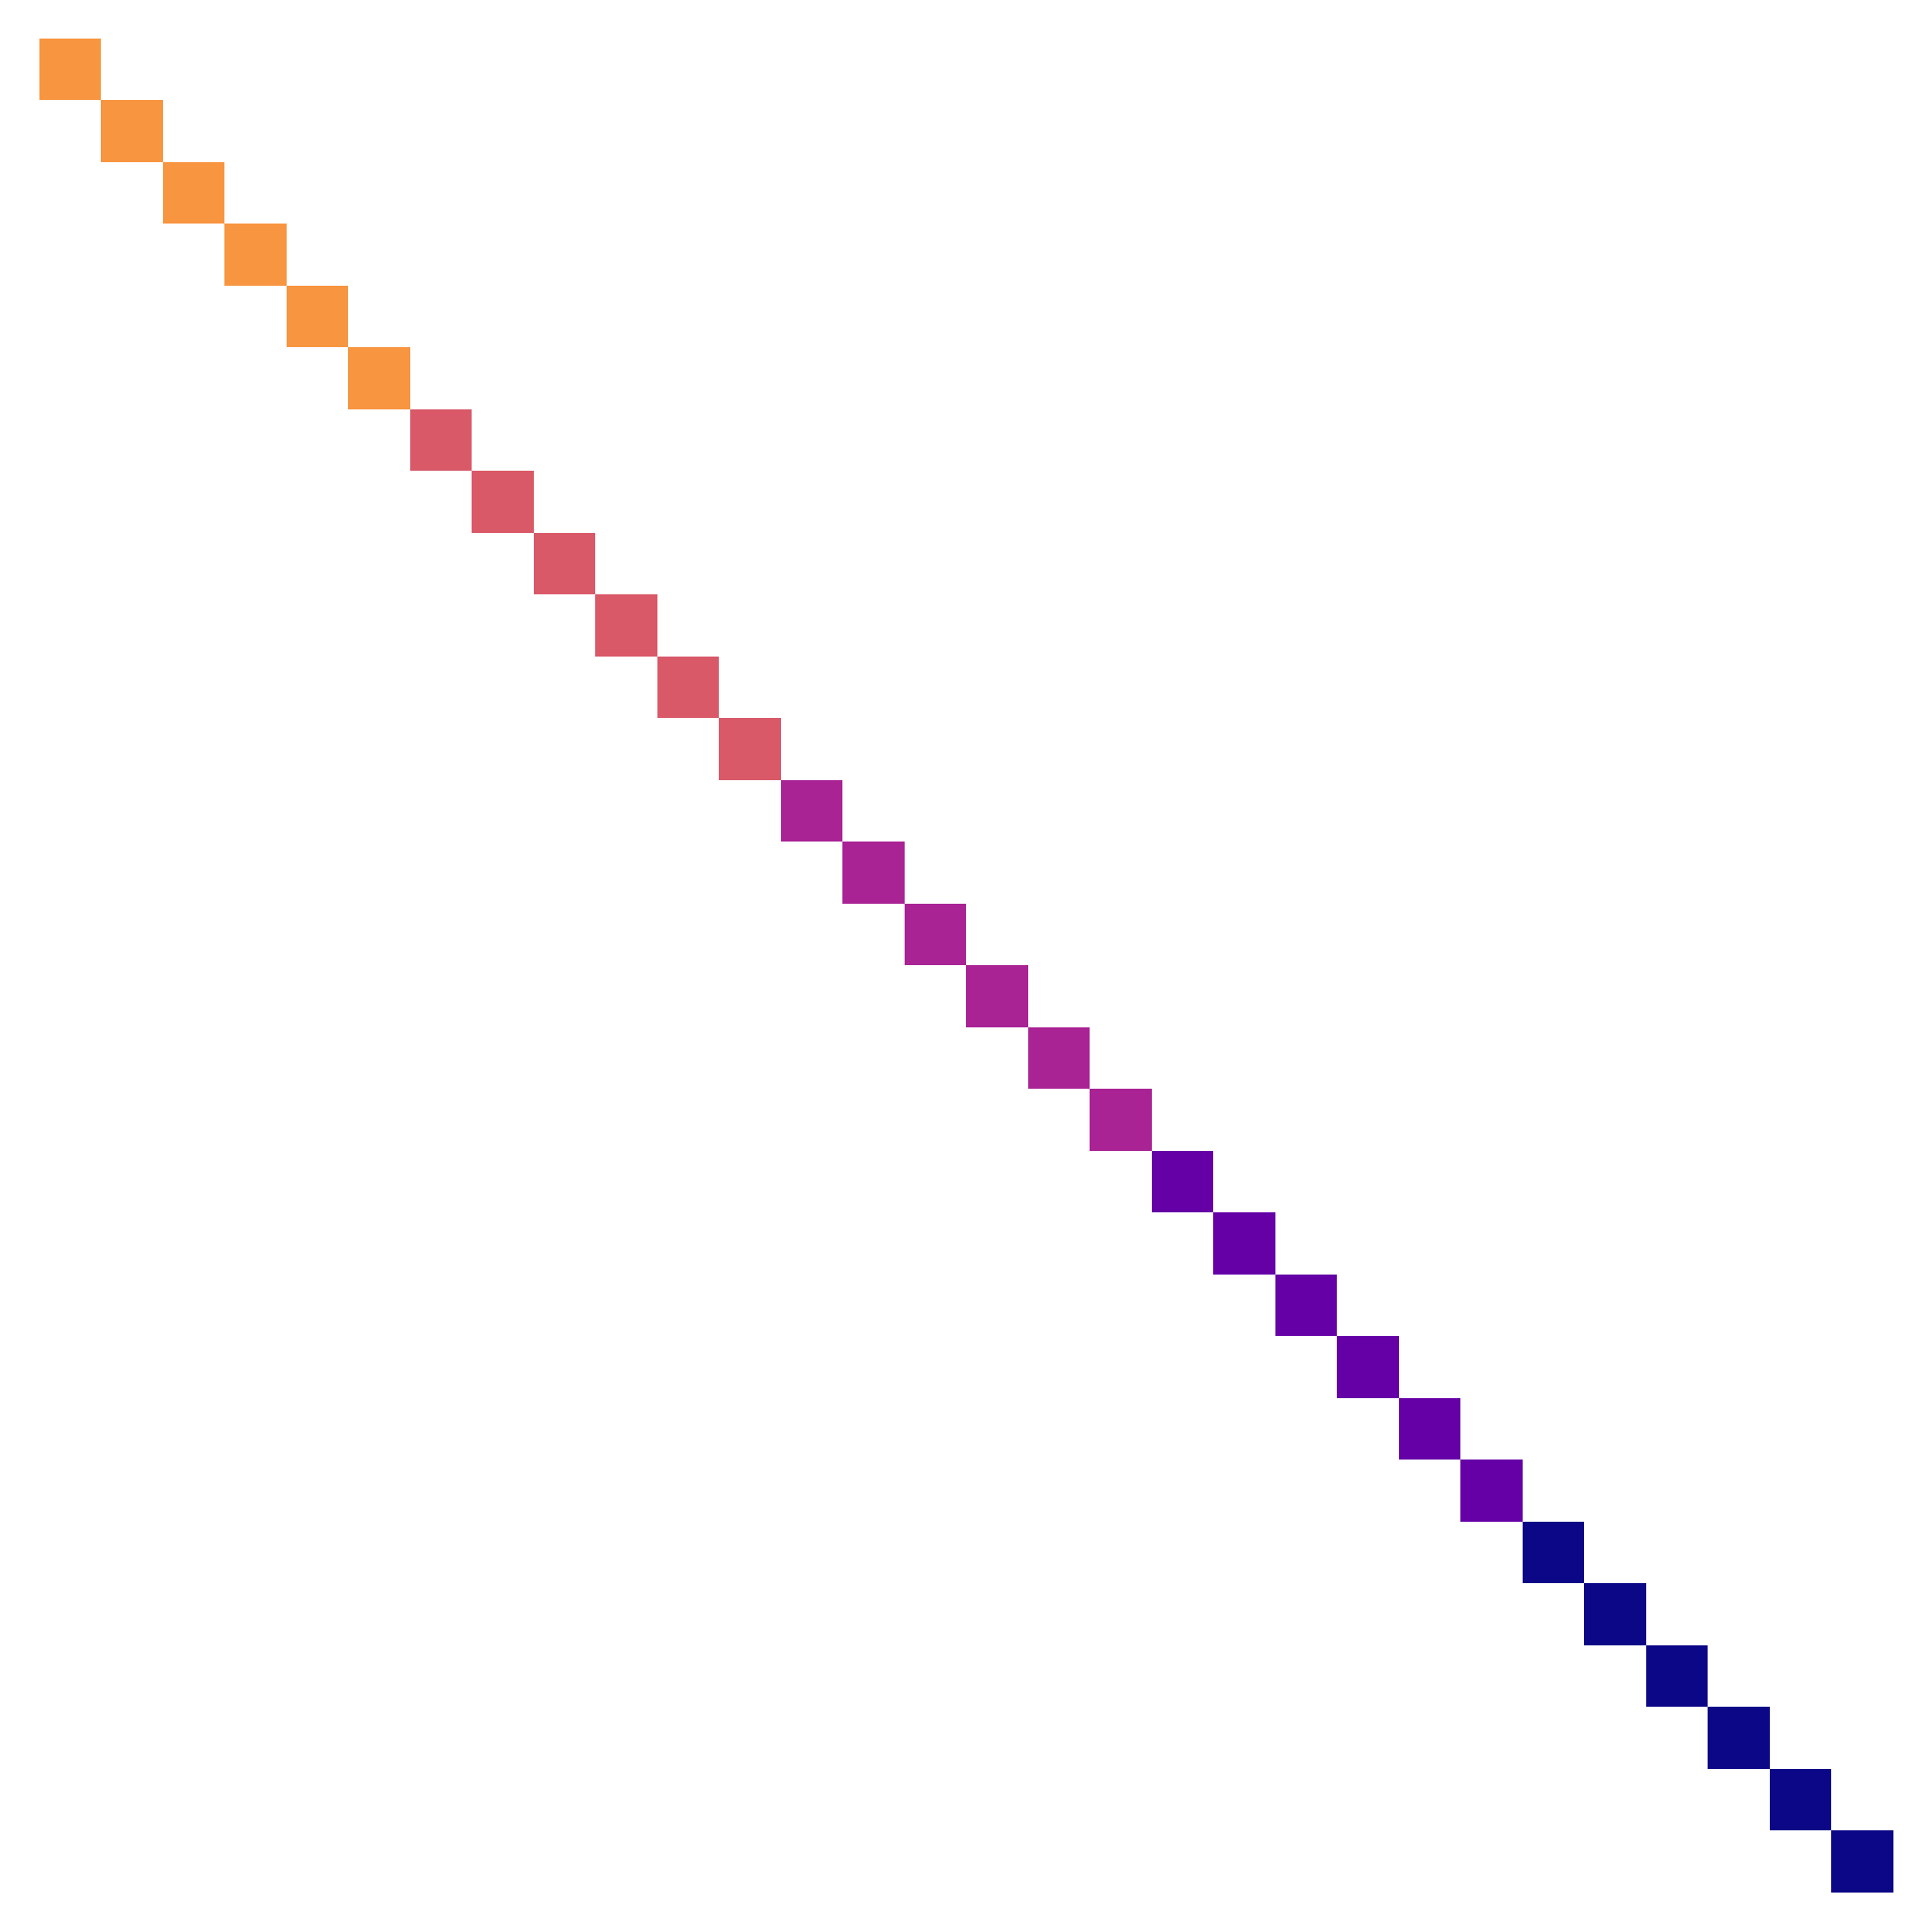

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# Same discrete 5-level colormap used before
# ------------------------------------------------------------
n_levels = 5
cmap = plt.cm.plasma
color_values = np.linspace(0.75, 0.0, n_levels)   # LF → HF mapping preserved
colors = [cmap(c) for c in color_values]          # 5 RGBA colors

# ------------------------------------------------------------
# Number of time steps per trajectory
# (replace Nt to match your real data)
# ------------------------------------------------------------
Nt = 6

# Total matrix size
N = n_levels * Nt

# Initialize matrix with zeros (white background)
W = np.zeros((N, N))

# Fill diagonal blocks only
start = 0
for k in range(n_levels):
    for i in range(Nt):
        W[start+i,start+i] = k+1
    start += Nt

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5), dpi=450)

# White for 0, then 5 discrete colors
cmap_discrete = ListedColormap(["white"] + colors)
bounds = np.arange(-0.5, n_levels + 1.5, 1)
norm = BoundaryNorm(bounds, cmap_discrete.N)

# main image
im = ax.imshow(W, cmap=cmap_discrete, norm=norm, interpolation="nearest")

# ------------------------------------------------------------
# Draw grid lines to reveal white squares
# ------------------------------------------------------------
ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
ax.set_yticks(np.arange(-0.5, N, 1), minor=True)
ax.grid(False)
ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

# Remove spines
for spine in ax.spines.values():
    spine.set_linewidth(0)

plt.tight_layout()
plt.savefig("sindy_weight_matrix_blocks_grid.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()


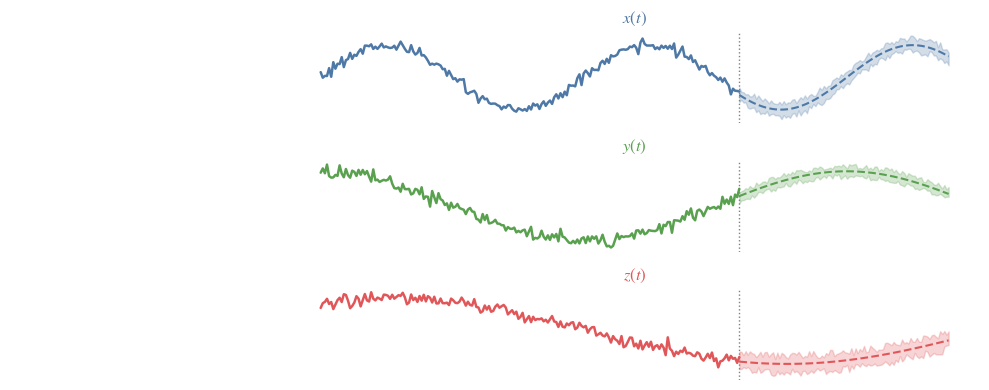

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# ---------------- synthetic forecasting data ----------------
np.random.seed(1)
t_hist = np.linspace(0, 10, 200)   # history
t_pred = np.linspace(10, 15, 100)  # forecasting horizon

def generate_series(f, noise=0.1):
    return f + noise*np.random.randn(len(f))

x_hist = generate_series(np.sin(t_hist))
y_hist = generate_series(np.cos(t_hist/2))
z_hist = generate_series(np.sin(t_hist/3+1))

x_fore_mean = np.sin(t_pred)
y_fore_mean = np.cos(t_pred/2)
z_fore_mean = np.sin(t_pred/3 + 1)

# add uncertainty envelopes
def make_uncertainty(mean, scale=0.3):
    upper = mean + scale*(0.5+np.random.rand(len(mean)))*0.5
    lower = mean - scale*(0.5+np.random.rand(len(mean)))*0.5
    return lower, upper

x_low, x_up = make_uncertainty(x_fore_mean, 0.4)
y_low, y_up = make_uncertainty(y_fore_mean, 0.3)
z_low, z_up = make_uncertainty(z_fore_mean, 0.5)

colors = {"x": "#4e79a7", "y": "#59a14f", "z": "#e15759"}

# ---------------- layout ----------------
fig = plt.figure(figsize=(10,4))
gs = fig.add_gridspec(3, 4, width_ratios=[1.2,1,1,1])

# equations block
ax_eq = fig.add_subplot(gs[:,0])
ax_eq.axis("off")

eqs = [
    (r"$\dot{x} = \Theta(\mathbf{u}) \langle \xi_1 \rangle$", "x"),
    (r"$\dot{y} = \Theta(\mathbf{u}) \langle \xi_2 \rangle$", "y"),
    (r"$\dot{z} = \Theta(\mathbf{u}) \langle \xi_3 \rangle$", "z"),
]


# ---------------- helper for series plot ----------------
def plot_forecast(ax, t_hist, hist, t_pred, pred_mean, low, up, var):
    ax.plot(t_hist, hist, color=colors[var], lw=1.8, label="data")
    ax.plot(t_pred, pred_mean, "--", color=colors[var], lw=1.5, label="forecast")
    ax.fill_between(t_pred, low, up, color=colors[var], alpha=0.25, label="uncertainty")
    ax.axvline(t_hist[-1], color="gray", ls=":", lw=1)  # split line
    ax.set_title(rf"${var}(t)$", fontsize=12, color=colors[var])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_frame_on(False)

# assign axes (rows aligned with equations)
ax_x = fig.add_subplot(gs[0,1:])
ax_y = fig.add_subplot(gs[1,1:])
ax_z = fig.add_subplot(gs[2,1:])

plot_forecast(ax_x, t_hist, x_hist, t_pred, x_fore_mean, x_low, x_up, "x")
plot_forecast(ax_y, t_hist, y_hist, t_pred, y_fore_mean, y_low, y_up, "y")
plot_forecast(ax_z, t_hist, z_hist, t_pred, z_fore_mean, z_low, z_up, "z")

# # ---------------- arrows for alignment ----------------
# def add_arrow(ax_from, ax_to, ypos_rel):
#     fig.canvas.draw()  # ensure positions updated
#     bbox_from = ax_from.get_position()
#     bbox_to   = ax_to.get_position()
#     x0 = bbox_from.x1
#     y0 = bbox_from.y0 + ypos_rel*bbox_from.height
#     x1 = bbox_to.x0
#     y1 = bbox_to.y0 + ypos_rel*bbox_to.height
#     arrow = FancyArrowPatch((x0,y0), (x1,y1),
#                             transform=fig.transFigure,
#                             arrowstyle="->", mutation_scale=12,
#                             lw=1.2, color="black")
#     fig.patches.append(arrow)

# add_arrow(ax_eq, ax_x, 0.8)
# add_arrow(ax_eq, ax_y, 0.5)
# add_arrow(ax_eq, ax_z, 0.2)

plt.tight_layout()
plt.savefig("esindy_forecast.png", dpi=300, transparent=True)
plt.show()
